# LSTM example without predictors (economist)
This dataset was produced from US economic time series data available from https://fred.stlouisfed.org/.

Variables:

1. date - Month of data collection
2. pce - personal consumption expenditures, in billions of dollars, https://fred.stlouisfed.org/series/PCE
3. pop - total population, in thousands, https://fred.stlouisfed.org/series/POP
4. psavert - personal savings rate, https://fred.stlouisfed.org/series/PSAVERT/
5. uempmed - median duration of unemployment, in weeks, https://fred.stlouisfed.org/series/UEMPMED
6. unemploy - number of unemployed in thousands, https://fred.stlouisfed.org/series/UNEMPLOY

We want to predict the unemployment in the following 12 months (*unemploy* variable).

# Libs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dropout, TimeDistributed, Dense, Input

from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [ ]:
print(tf.__version__)

2.18.0


# Data load

In [ ]:
df = pd.read_csv('economics.csv', index_col = 0)
df.head()

,date,pce,pop,psavert,uempmed,unemploy
1,1967-07-01,506.7,198712.0,12.6,4.5,2944
2,1967-08-01,509.8,198911.0,12.6,4.7,2945
3,1967-09-01,515.6,199113.0,11.9,4.6,2958
4,1967-10-01,512.2,199311.0,12.9,4.9,3143
5,1967-11-01,517.4,199498.0,12.8,4.7,3066


<ipython-input-3-74a3b3ebfd50>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['date'] = pd.date_range(start='1967-07-01', periods=len(df), freq='M')


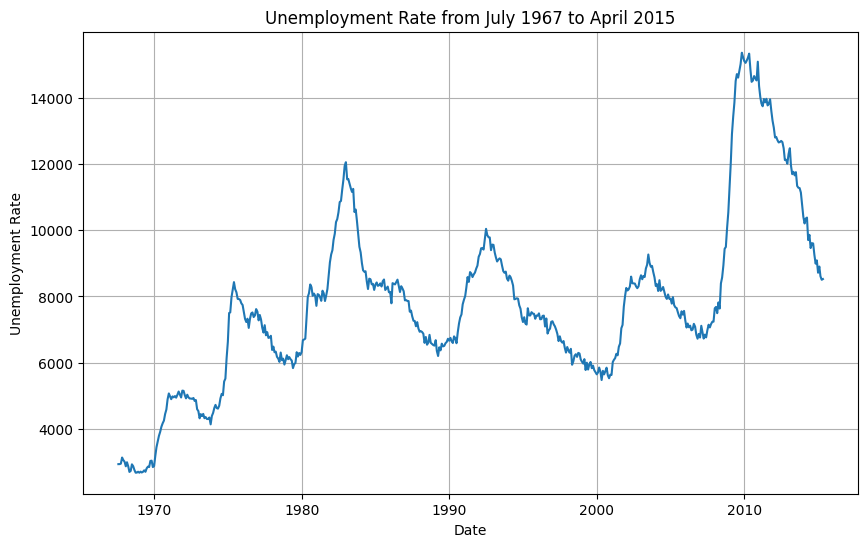

In [ ]:
df['date'] = pd.date_range(start='1967-07-01', periods=len(df), freq='M')
df.set_index('date', inplace=True)

# Plotting the time series
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['unemploy'], label='Unemployment Rate')
plt.title('Unemployment Rate from July 1967 to April 2015')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.grid(True)
plt.show()

# Scaling data

LSTM requires to rescale the input data. Mean and standard deviation of the training data set can be used as the scaling coefficients to scale both the training and testing data sets as well as the predicted values.

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the 'unemploy' column
df['unemploy'] = scaler.fit_transform(df[['unemploy']])

df.head()

,pce,pop,psavert,uempmed,unemploy
date,,,,,
1967-07-31,506.7,198712.0,12.6,4.5,-1.828764
1967-08-31,509.8,198911.0,12.6,4.7,-1.828385
1967-09-30,515.6,199113.0,11.9,4.6,-1.823461
1967-10-31,512.2,199311.0,12.9,4.9,-1.753376
1967-11-30,517.4,199498.0,12.8,4.7,-1.782546


# Tensors

LSTM algorithm creates predictions based on the lagged values. That means that it needs to look back to as many previous values as many points we wish to predict. As we want to do a 12 months forecast, we need to base each prediction on 12 data points.

Additionally *keras* expects specific tensor format of shape of a 3D array of the form [samples, timesteps, features] for predictors (X) and for target (Y) values:

1. Samples specifies the number of observations which will be processed in batches: (nrow(data) – lag – prediction + 1).
2. Timesteps tells us the number of time steps (lags). Or in other words how many units back in time we want our network to see: (12)
3. Features specifies number of predictors (1 for univariate series and *n* for multivariate).

In [ ]:
prediction = 12
lag = prediction
features = 1

df_train = df.copy()

We lag the data 11 times, so that each prediction is based on 12 values, and arrange lagged values into columns. Then we transform it into the desired 3D form. Basically every column is a lagged version of the previous one – the last one is lagged by 11 steps comparing to the first one.

In [ ]:
# Create lagged data for X
df_train_x_lag = np.array([df_train['unemploy'].values[i:(i + lag)]
                           for i in range(len(df_train) - lag - prediction + 1)])

# Convert to tensor format
df_train_x_tensor = df_train_x_lag.reshape((df_train_x_lag.shape[0], lag, features))

# Create lagged data for Y
df_train_y_lag = np.array([df_train['unemploy'].values[(i + 1):(i + lag + 1)]
                           for i in range(len(df_train) - lag - prediction + 1)])

# Convert to tensor format
df_train_y_tensor = df_train_y_lag.reshape((df_train_y_lag.shape[0], lag, features))

# Print shapes to verify
print("Shape of df_train_x_tensor:", df_train_x_tensor.shape)
print("Shape of df_train_y_tensor:", df_train_y_tensor.shape)
print(df_train_x_tensor)

Shape of df_train_x_tensor: (551, 12, 1)
Shape of df_train_y_tensor: (551, 12, 1)
[[[-1.82876428]
  [-1.82838544]
  [-1.82346056]
  ...
  [-1.91779101]
  [-1.90604705]
  [-1.8310373 ]]

 [[-1.82838544]
  [-1.82346056]
  [-1.75337569]
  ...
  [-1.90604705]
  [-1.8310373 ]
  [-1.85187335]]

 [[-1.82346056]
  [-1.75337569]
  [-1.78254615]
  ...
  [-1.8310373 ]
  [-1.85187335]
  [-1.89543962]]

 ...

 [[ 1.48416638]
  [ 1.51106381]
  [ 1.47090708]
  ...
  [ 0.99736067]
  [ 0.92083557]
  [ 0.97652463]]

 [[ 1.51106381]
  [ 1.47090708]
  [ 1.50765428]
  ...
  [ 0.92083557]
  [ 0.97652463]
  [ 0.98826858]]

 [[ 1.47090708]
  [ 1.50765428]
  [ 1.35005803]
  ...
  [ 0.97652463]
  [ 0.98826858]
  [ 0.73141701]]]


In the same manner we need to prepare input data for the prediction, which are in fact last 12 observations from our training set.

In [ ]:
# Extract the test data for the specified period
df_test = df['unemploy'][-(lag + prediction):]

# Ensure that the test data is normalized using the same scale factors
df_test = scaler.transform(df_test.values.reshape(-1, 1)).flatten()

# Create the test tensor with one sample for the specified lag period
df_test_tensor = df_test[:lag].reshape((1, lag, 1))

# Print the shape to verify
print("Shape of df_test_tensor:", df_test_tensor.shape)
print(df_test_tensor)

Shape of df_test_tensor: (1, 12, 1)
[[[-2.94350354]
  [-2.94348962]
  [-2.94354932]
  [-2.94355736]
  [-2.94355865]
  [-2.94357788]
  [-2.94362797]
  [-2.94368294]
  [-2.94371193]
  [-2.94369083]
  [-2.94368638]
  [-2.94378369]]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## LSTM model

In [ ]:
# First LSTM layer with 50 units, stateful, and return sequences
lstm_model = Sequential([
    Input(batch_shape=(1, 12, 1)),  # 1 - batch size, 12 - timesteps, 1 - feature
    LSTM(units=50, return_sequences=True, stateful=True),
    Dropout(rate=0.25),
    LSTM(units=50, return_sequences=True, stateful=True),
    Dropout(rate=0.25),
    TimeDistributed(Dense(units=1)) # TimeDistributed layer to apply a dense layer to each timestep
])

# Compile the model
lstm_model.compile(
    loss='mean_absolute_error',
    optimizer=Adam(),
    metrics=['mean_absolute_percentage_error', 'mean_squared_error']
)

# Print the model summary
lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (1, 12, 50)            │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (1, 12, 50)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (1, 12, 50)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (1, 12, 50)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (1, 12, 1)             │            51 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

The return_sequences parameter in LSTM (or other recurrent layers such as GRU) is used to control whether the layer should return the full sequence of outputs for each input sequence or only the output at the last time step.

**return_sequences=False (default):**

The layer will return only the output of the last time step for each input sequence.
This is useful when you are interested only in the final output after processing the entire sequence (e.g., for sequence classification tasks).

**return_sequences=True:**

The layer will return the full sequence of outputs for each input sequence.
This means that for an input sequence of length T, the layer will return a sequence of length T. This is useful when you need the output at each time step (e.g., for tasks where the prediction is needed at each time step, such as in time series forecasting or in sequence-to-sequence models).


1. Stacking LSTM Layers: When stacking multiple LSTM layers, the subsequent LSTM layer expects a sequence as input. Therefore, the previous LSTM layer must output the full sequence of hidden states (not just the last hidden state).
2. TimeDistributed Layer: The final layer in the model is a TimeDistributed dense layer, which applies a dense layer to each time step in the sequence. For this to work, the previous LSTM layer must output the full sequence (hence return_sequences=True).

The stateful parameter in LSTM (or other recurrent layers such as GRU) controls whether the hidden states are carried over from one batch to the next. When stateful=True, the model maintains the state of the LSTM cells across different batches, which can be useful for certain time series or sequence data applications.

**stateful=False (default):**

The hidden states are reset at the start of each batch. This is suitable for most applications where the sequences in each batch are independent of each other. For example, in many natural language processing tasks, each sentence or sequence is independent, so there is no need to carry over the state between batches.

**stateful=True:**

The hidden states are not reset at the start of each batch. Instead, the state from the end of one batch is used as the initial state for the next batch. This is useful for time series data where the sequences are continuous and you want to preserve the temporal dependencies across batches.

**Key Points When Using stateful=True:**

1. Consistent Batch Size: The batch size must be fixed. All batches should have the same size because the hidden states are carried over between batches.
2. Shuffling: Shuffling the data is not allowed between epochs because it would disrupt the continuity of the sequences.
3. Resetting States: You may need to manually reset the states of the LSTM layer using model.reset_states() at appropriate times.

# LSTM fit

Epoch 1/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.2912 - mean_absolute_percentage_error: 74.7136 - mean_squared_error: 0.2149
Epoch 2/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.2282 - mean_absolute_percentage_error: 74.9742 - mean_squared_error: 0.1168
Epoch 3/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2630 - mean_absolute_percentage_error: 71.5465 - mean_squared_error: 0.1705
Epoch 4/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2520 - mean_absolute_percentage_error: 69.1940 - mean_squared_error: 0.1670
Epoch 5/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2664 - mean_absolute_percentage_error: 60.4688 - mean_squared_error: 0.1838
Epoch 6/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2262 - mean_absolute_percentage_error: 57.1248 - mean_squared_error: 0.1315
Epoch 7/20
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2215 - mean_absolute_percentage_error: 54.3191 - mean_squared_error: 0.1248
Epoch 8/20
551/551 ━━━━━━━━━━━━━━━

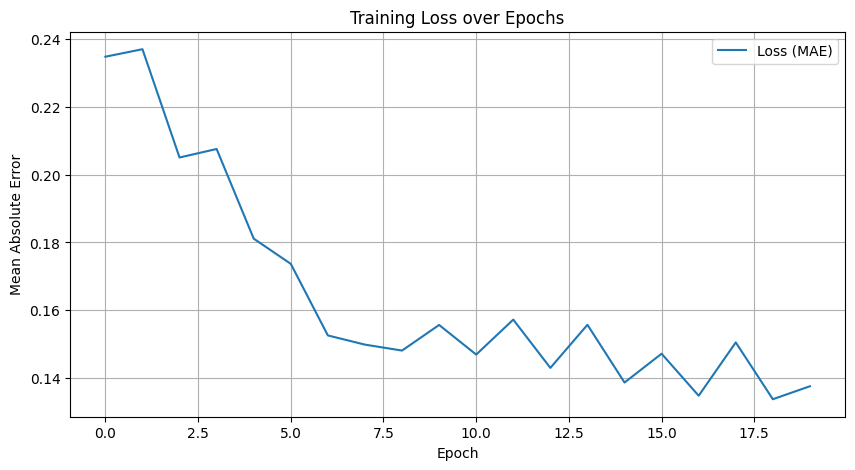

In [ ]:
# Train the model
history = lstm_model.fit(
    x=df_train_x_tensor,
    y=df_train_y_tensor,
    batch_size=1,       # Each batch contains 1 sample
    epochs=20,          # Number of epochs
    verbose=1,          # Verbosity mode
    shuffle=False       # Maintain the order of the dataset
)

# Reset states after training
#lstm_model.reset_states()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss (MAE)')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


# Make predictions

In [ ]:
lstm_forecast = lstm_model.predict(df_test_tensor, batch_size=1)
lstm_forecast = lstm_forecast.flatten()

# Rescale the forecast
lstm_forecast = scaler.inverse_transform(lstm_forecast.reshape(-1, 1)).flatten()

# Create the forecast DataFrame
dates = pd.date_range(start=df.index[-1] - pd.DateOffset(months=lag-1), periods=lag, freq='M')
df_forecast = pd.DataFrame({'date': dates, 'unemploy': lstm_forecast})

# Print the forecast DataFrame
print(df_forecast)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
         date     unemploy
0  2014-05-31  6608.962402
1  2014-06-30  5345.993652
2  2014-07-31  4901.055176
3  2014-08-31  4726.441406
4  2014-09-30  4653.079590
5  2014-10-31  4682.227539
6  2014-11-30  4592.196289
7  2014-12-31  4468.229492
8  2015-01-31  4381.141113
9  2015-02-28  4331.891113
10 2015-03-31  4304.416992
11 2015-04-30  4288.305664


<ipython-input-33-50b4528168b7>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=df.index[-1] - pd.DateOffset(months=lag-1), periods=lag, freq='M')


In [ ]:
# Prepare ARIMA model data (excluding the last 12 months for forecasting)
df_arima = df['unemploy'][:-12]
ts_arima = df_arima.values

# Fit ARIMA model
model_arima = ARIMA(ts_arima, order=(5, 1, 0))
model_arima_fit = model_arima.fit()

# Forecast the next 12 months
forecast_arima = model_arima_fit.forecast(steps=12)
print(forecast_arima)

forecast_arima_original_scale = scaler.inverse_transform(forecast_arima.reshape(-1, 1)).flatten()
print(forecast_arima_original_scale)

[0.70173153 0.65454503 0.61200633 0.56719776 0.51659199 0.48972517
 0.46144778 0.43657406 0.41461173 0.39534351 0.37983702 0.3657513 ]
[9623.64052652 9499.08434901 9386.79679774 9268.51753279 9134.93568549
 9064.01649338 8989.37387882 8923.71580515 8865.74277826 8814.8812991
 8773.94949541 8736.76801483]


In [ ]:
forecast_arima_df = pd.DataFrame({'date': dates, 'unemploy': forecast_arima_original_scale})

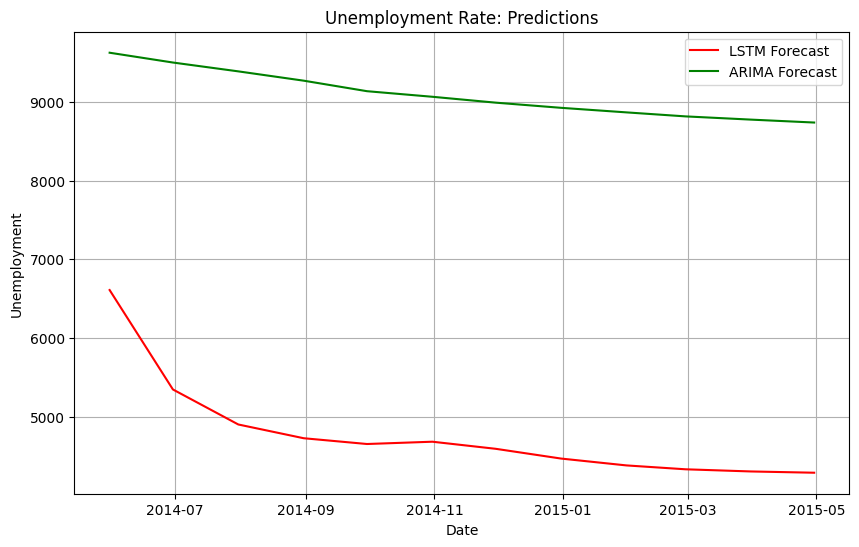

In [ ]:
# Plotting the actual and forecasted unemployment rates
plt.figure(figsize=(10, 6))

plt.plot(df_forecast['date'], df_forecast['unemploy'], label='LSTM Forecast', color='red')
plt.plot(forecast_arima_df['date'], forecast_arima_df['unemploy'], label='ARIMA Forecast', color='green')
plt.xlabel('Date')
plt.ylabel('Unemployment')
plt.title('Unemployment Rate: Predictions')
plt.legend()
plt.grid(True)
plt.show()

# Exercise (Predicting passangers) - 45 minutes

Dataset *air_passengers.csv* contains the classic Box–Jenkins airline data: a monthly time series of international airline passengers (in thousands) from 1949 to 1960. Build an LSTM model to predict the last 12 months of the series, using the remaining observations as the training set.